# СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГРАФОВЫХ МОДЕЛЕЙ

In [8]:
import os
import igraph as ig
import pandas as pd

def generate_or_load_graphs(force_regenerate=False, files=['er.pkl', 'ba.pkl', 'ws.pkl'], params=[100, 0.03, 2, 4, 0.1]):    
    n, er_p, ba_m, ws_k, ws_p = params
    
    if not force_regenerate and all(os.path.exists(f) for f in files):
        er_graph = ig.Graph.Read_Pickle(files[0])
        ba_graph = ig.Graph.Read_Pickle(files[1])
        ws_graph = ig.Graph.Read_Pickle(files[2])
    else:
        er_graph = ig.Graph.Erdos_Renyi(n=n, p=er_p)
        ba_graph = ig.Graph.Barabasi(n=n, m=ba_m)
        ws_graph = ig.Graph.Watts_Strogatz(dim=1, size=n, nei=ws_k // 2, p=ws_p)
        
        er_graph.write_pickle(files[0])
        ba_graph.write_pickle(files[1])
        ws_graph.write_pickle(files[2])
    
    return er_graph, ba_graph, ws_graph

er, ba, ws = generate_or_load_graphs()

def get_graph_params(graph: ig.Graph) -> dict:
    components = graph.components()

    return {
        "avg_degree": sum(graph.degree()) / graph.vcount(),
        "avg_clustering": graph.transitivity_avglocal_undirected(),
        "global_clustering": graph.transitivity_undirected(),
        "diameter": graph.diameter(),
        "avg_path_length": graph.average_path_length(),
        "density": graph.density(),
        "num_components": len(components),
        "giant_component_size": components.giant().vcount(),
    }

df = pd.DataFrame({
    "Erdos_Renyi": get_graph_params(er),
    "Barabasi_Albert": get_graph_params(ba),
    "Watts_Strogatz": get_graph_params(ws)
}).reset_index().rename(columns={"index": "model"}).round(4)
display(df)

,model,Erdos_Renyi,Barabasi_Albert,Watts_Strogatz
0,avg_degree,4.4800,3.9400,4.0000
1,avg_clustering,0.0192,0.1385,0.2510
2,global_clustering,0.0224,0.0607,0.2366
3,diameter,7.0000,6.0000,8.0000
4,avg_path_length,3.2331,3.0853,4.0895
5,density,0.0453,0.0398,0.0404
6,num_components,1.0000,1.0000,1.0000
7,giant_component_size,100.0000,100.0000,100.0000


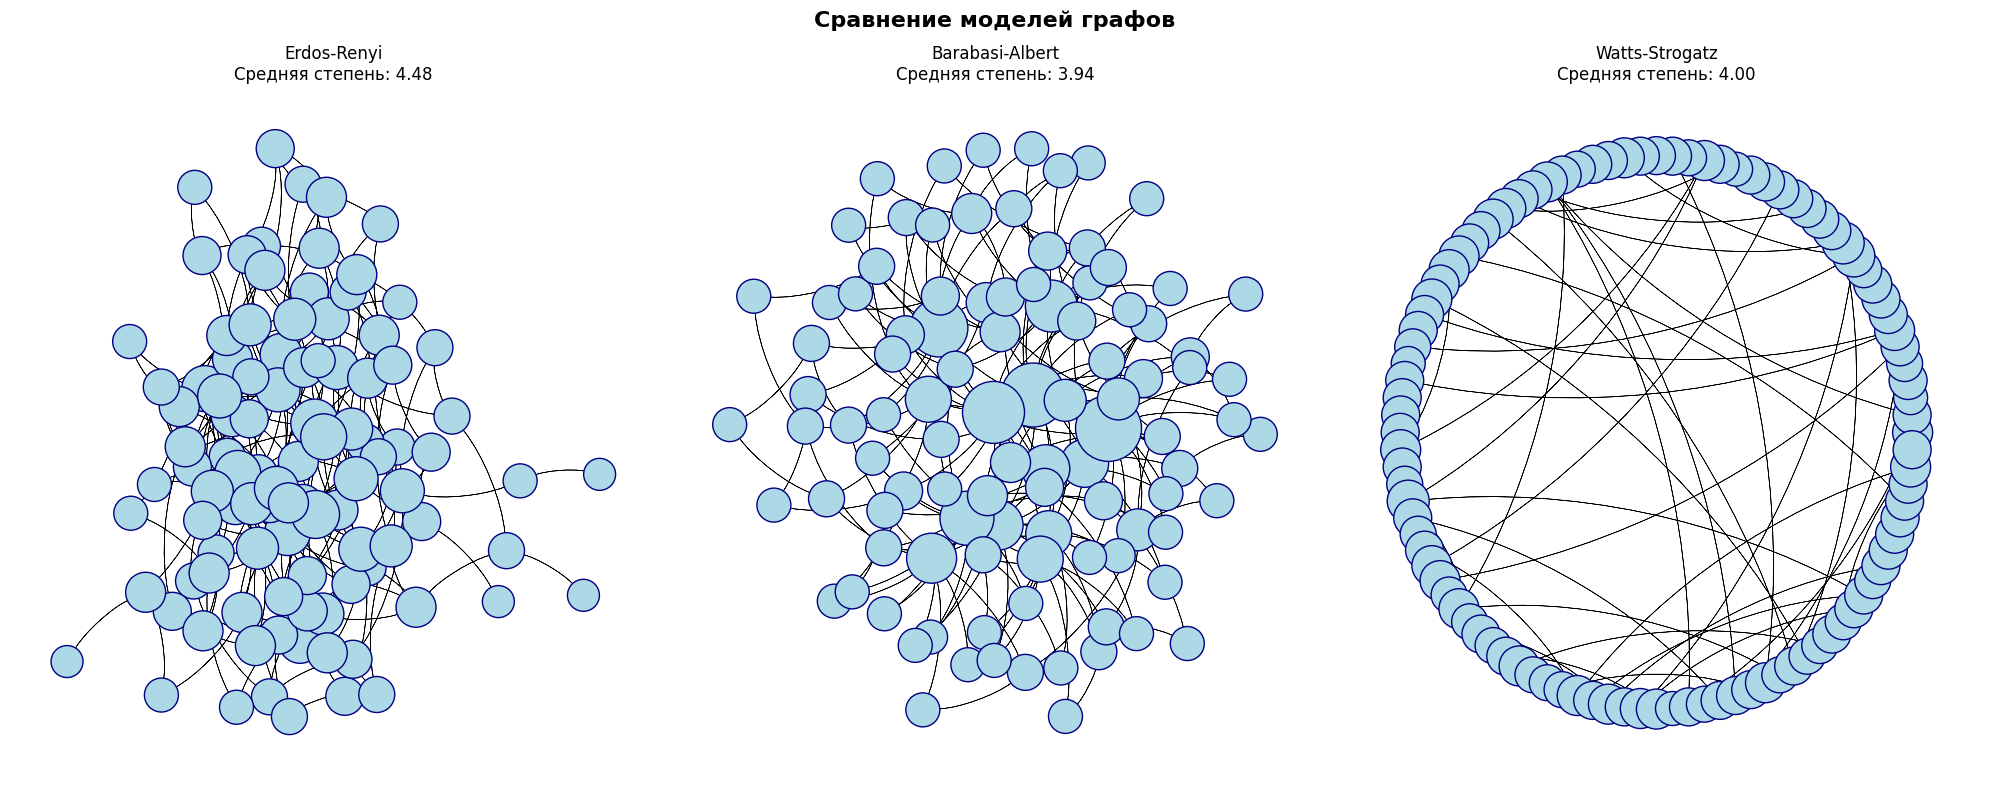

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_graphs(graphs: list[ig.Graph]):
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    fig.suptitle('Сравнение моделей графов', fontsize=16, fontweight='bold')

    titles = ['Erdos-Renyi', 'Barabasi-Albert', 'Watts-Strogatz']

    for i, (graph, title) in enumerate(zip(graphs, titles)):
        degrees = graph.degree()

        if i == 0:
            layout = graph.layout_fruchterman_reingold()
        elif i == 1:
            layout = graph.layout_kamada_kawai()
        else:
            layout = graph.layout_circle()
        
        ig.plot(
            graph,
            target=axes[i],
            layout=layout,
            vertex_size=[30 + d*2 for d in degrees],
            vertex_color='lightblue',
            vertex_frame_width=1,
            vertex_frame_color='navy',
            edge_width=0.5,
            edge_color='black',
            edge_curved=0.2,
            margin=40
        )
        axes[i].set_title(f'{title}\nСредняя степень: {np.mean(degrees):.2f}', fontsize=12)

    plt.tight_layout()
    plt.show()

visualize_graphs([er, ba, ws])

C:\Users\maksi\AppData\Local\Temp\ipykernel_22232\1937569037.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


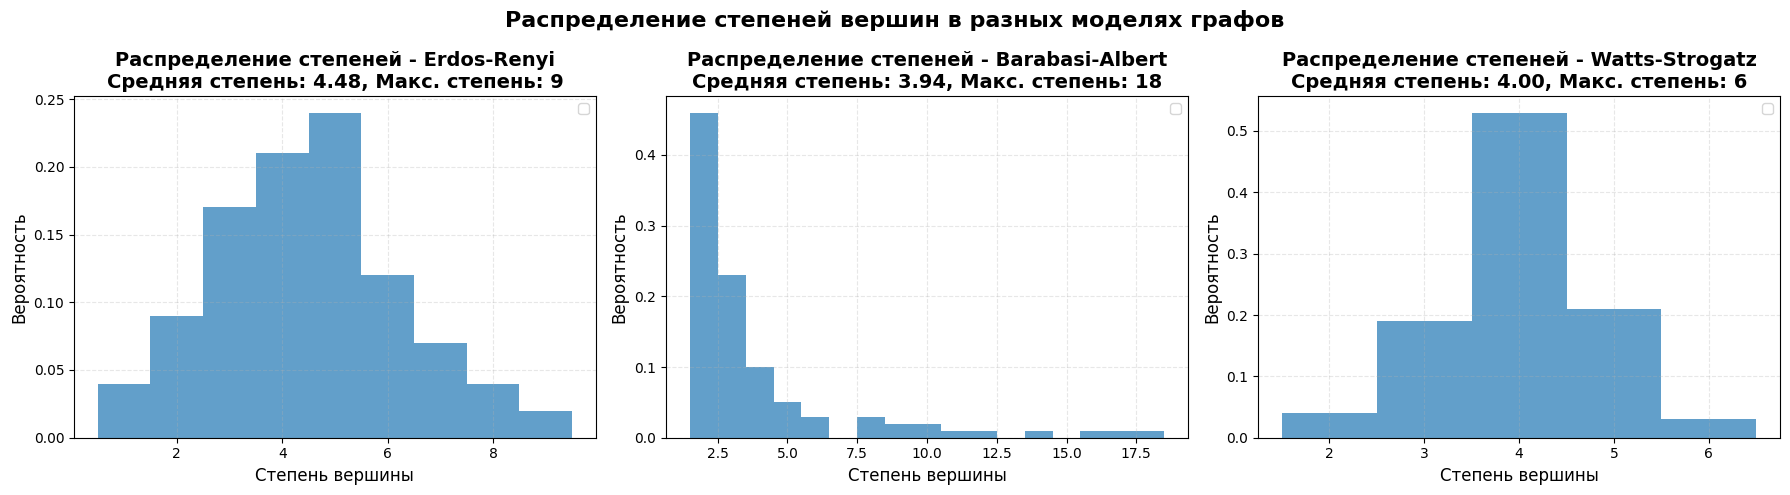

In [16]:
from collections import Counter

def plot_degree_distribution(graph, model_name="", ax=None, bins=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    degrees = graph.degree()
    
    if not bins:
        bins = np.arange(min(degrees), max(degrees) + 2) - 0.5
    
    ax.hist(degrees, bins=bins, density=True, alpha=0.7)
    
    avg_degree = np.mean(degrees)
    max_degree = np.max(degrees)
    
    ax.set_xlabel('Степень вершины', fontsize=12)
    ax.set_ylabel('Вероятность', fontsize=12)
    
    title = f'Распределение степеней'
    if model_name:
        title += f' - {model_name}'
    title += f'\nСредняя степень: {avg_degree:.2f}, Макс. степень: {max_degree}'
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best')
    ax.set_ylim(bottom=0)
    
    return ax


def plot_all_degree_distributions(er_graph, ba_graph, ws_graph):    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Распределение степеней вершин в разных моделях графов', 
                 fontsize=16, fontweight='bold')
    
    plot_degree_distribution(er_graph, "Erdos-Renyi", axes[0])
    plot_degree_distribution(ba_graph, "Barabasi-Albert", axes[1])
    plot_degree_distribution(ws_graph, "Watts-Strogatz", axes[2])
    
    plt.tight_layout()
    plt.show()

plot_all_degree_distributions(er, ba, ws)

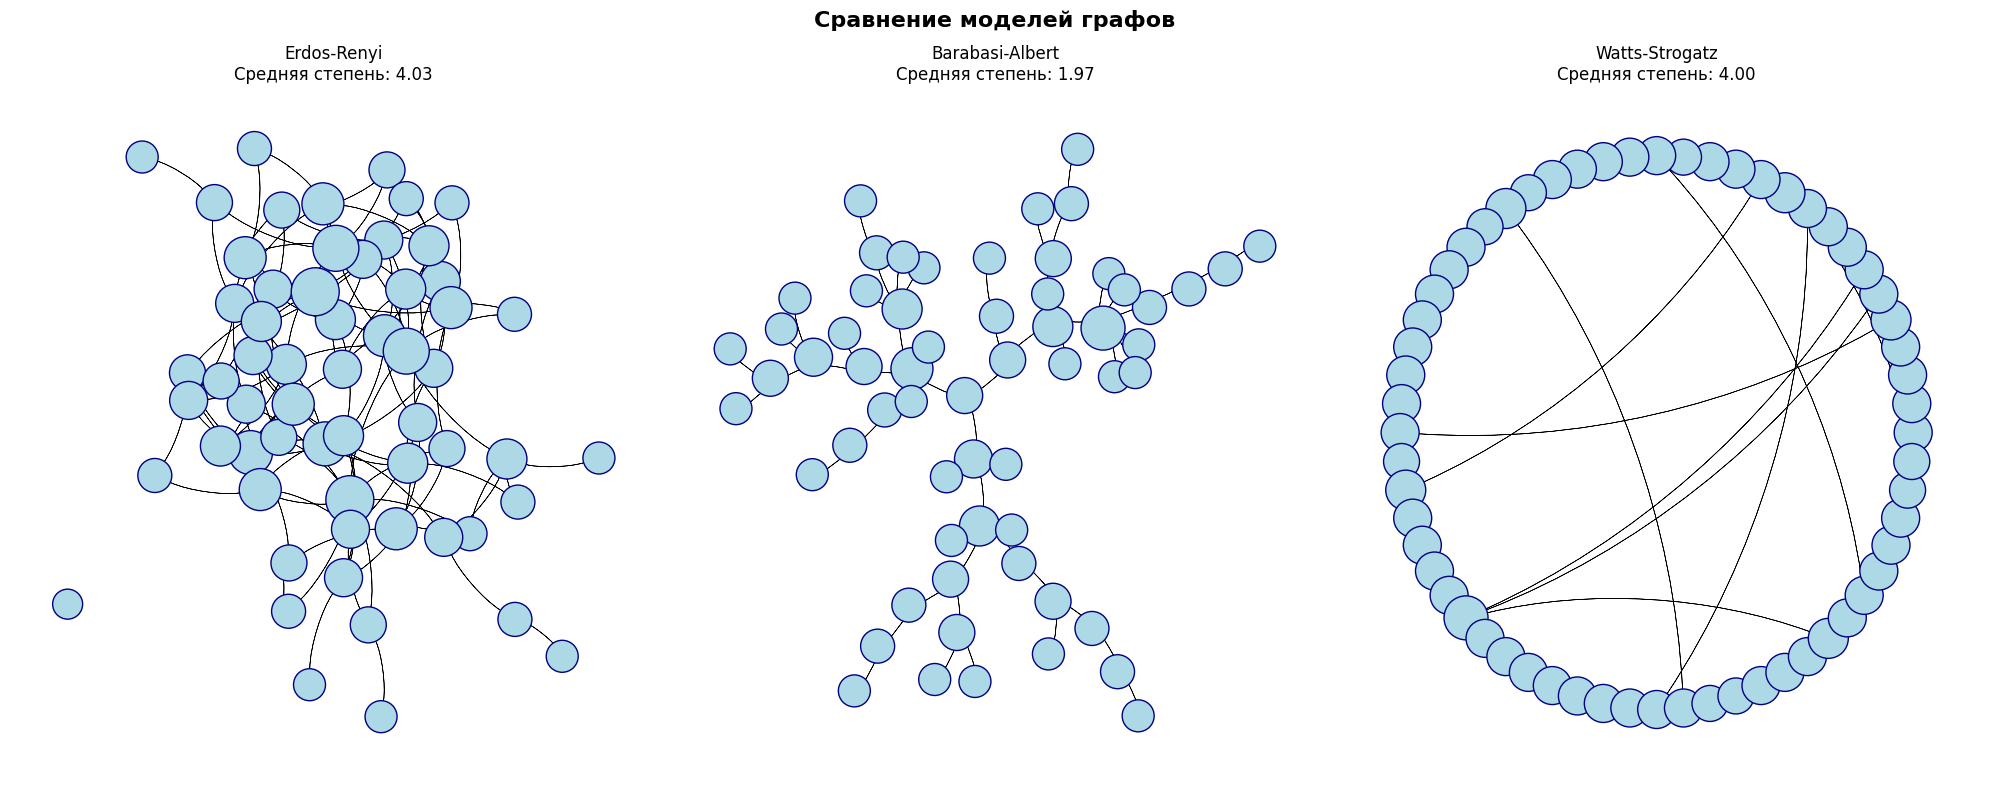

C:\Users\maksi\AppData\Local\Temp\ipykernel_22232\1937569037.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


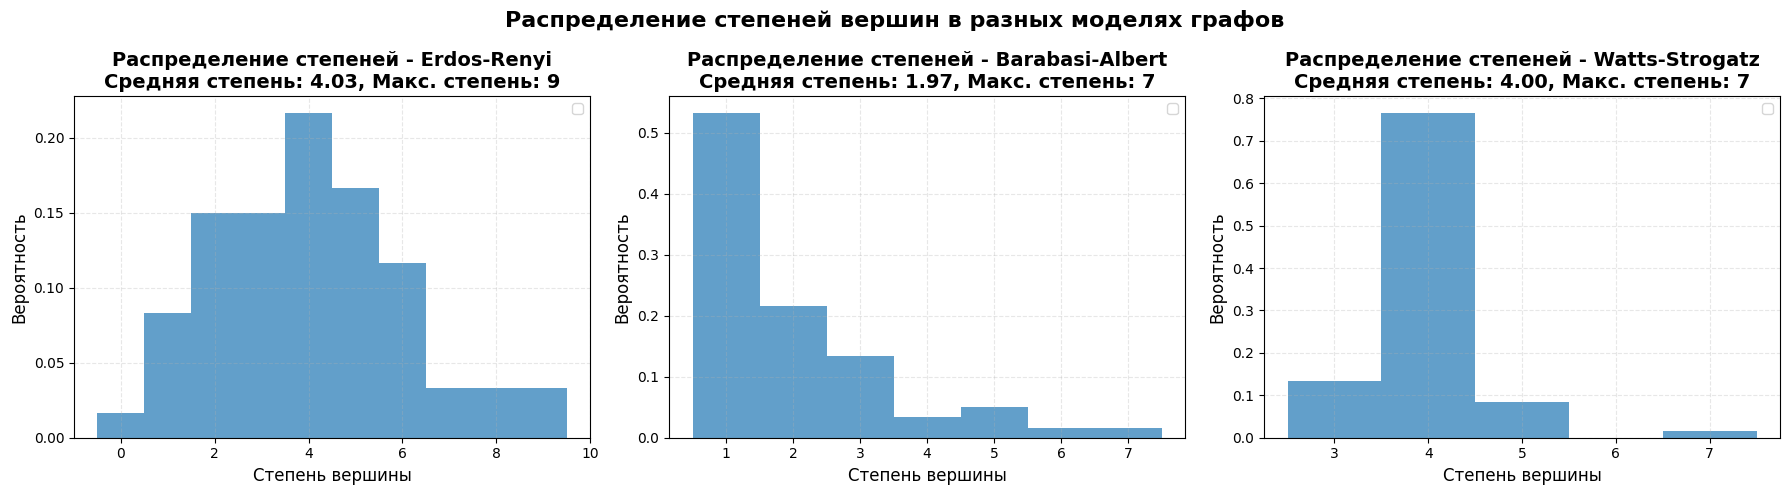

In [17]:
# Влияние параметров, другой вариант.

er1, ba1, ws1 = generate_or_load_graphs(files=['er1.pkl', 'ba1.pkl', 'ws1.pkl'], params=[60, 0.07, 1, 4, 0.05])

visualize_graphs([er1, ba1, ws1])
plot_all_degree_distributions(er1, ba1, ws1)

In [12]:
df = pd.DataFrame({
    "Erdos_Renyi_10": get_graph_params(er1),
    "Barabasi_Albert_10": get_graph_params(ba1),
    "Watts_Strogatz_10": get_graph_params(ws1)
}).reset_index().rename(columns={"index": "model"}).round(4)
display(df)

,model,Erdos_Renyi_10,Barabasi_Albert_10,Watts_Strogatz_10
0,avg_degree,4.0333,1.9667,4.0000
1,avg_clustering,0.0505,0.0000,0.3940
2,global_clustering,0.0613,0.0000,0.3720
3,diameter,7.0000,14.0000,8.0000
4,avg_path_length,2.9860,5.9446,4.0949
5,density,0.0684,0.0333,0.0678
6,num_components,2.0000,1.0000,1.0000
7,giant_component_size,59.0000,60.0000,60.0000
